We will use Runge's function (see
\url{https://en.wikipedia.org/wiki/Runge\%27s_phenomenon} for a
discussion). The one-dimensional function we will study is

$$
f(x) = \frac{1}{1+25x^2}.
$$

Our first step will be to perform an OLS regression analysis of this
function, trying out a polynomial fit with an $x$ dependence of the
form $[x,x^2,\dots]$. You can use a uniform distribution to set up the
arrays of values for $x \in [-1,1]$, or alternatively use a fixed step
size. Thereafter we will repeat many of the same steps when using the
Ridge and Lasso regression methods, introducing thereby a dependence on
the hyperparameter (penalty) $\lambda$.

We will also include bootstrap as a resampling technique in order to
study the so-called \textbf{bias-variance tradeoff}. After that we will
include the so-called cross-validation technique.

## Part A
### Ordinary Least Square (OLS) for the Runge function
We will generate our own dataset for abovementioned function
$\mathrm{Runge}(x)$ function with $x\in [-1,1]$. You should explore
also the addition of an added stochastic noise to this function using
the normal distribution $N(0,1)$.

\emph{Write your own code} (using for example the pseudoinverse function
\textbf{pinv} from \textbf{Numpy} ) and perform a standard
\textbf{ordinary least square regression} analysis using polynomials in
$x$ up to order $15$ or higher. Explore the dependence on the number
of data points and the polynomial degree.

Evaluate the mean Squared error (MSE)

$$
MSE(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}
\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2,
$$

and the $R^2$ score function. If $\tilde{\boldsymbol{y}}_i$ is the
predicted value of the $i-th$ sample and $y_i$ is the corresponding
true value, then the score $R^2$ is defined as

$$
R^2(\boldsymbol{y}, \tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n - 1} (y_i - \tilde{y}_i)^2}{\sum_{i=0}^{n - 1} (y_i - \bar{y})^2},
$$

where we have defined the mean value of $\boldsymbol{y}$ as

$$
\bar{y} =  \frac{1}{n} \sum_{i=0}^{n - 1} y_i.
$$

Plot the resulting scores (MSE and R$^2$) as functions of the
polynomial degree (here up to polymial degree 15). Plot also the
parameters $\theta$ as you increase the order of the polynomial.
Comment your results.

Your code has to include a scaling/centering of the data (for example by
subtracting the mean value), and a split of the data in training and
test data. For the scaling you can either write your own code or use for
example the function for splitting training data provided by the library
\textbf{Scikit-Learn} (make sure you have installed it). This function
is called $train\_test\_split$. \textbf{You should present a critical
discussion of why and how you have scaled or not scaled the data}.

It is normal in essentially all Machine Learning studies to split the
data in a training set and a test set (eventually also an additional
validation set). There is no explicit recipe for how much data should be
included as training data and say test data. An accepted rule of thumb
is to use approximately $2/3$ to $4/5$ of the data as training data.

You can easily reuse the solutions to your exercises from week 35. See
also the lecture slides from week 35 and week 36.

On scaling, we recommend reading the following section from the
scikit-learn software description, see
\url{https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html\#plot-all-scaling-standard-scaler-section}.


$$ \boldsymbol{\hat{\theta}_{OLS}} = (\boldsymbol{X}^T \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{y} $$

In [60]:
import numpy as np

def OLS_parameters(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

# Create a feature matrix X for the features. Here we use polynomial features up to degree 5, plus an intercept column of ones.
def polynomial_features(x, p):
    n = len(x)
    X = np.zeros((n, p + 1))
    for i in range(p + 1):
        X[:, i] = x**i
    return X

def runge_function(x):
    return 1 / (1 + 25 * x**2)

# Generate synthetic data
n = 1000
x = np.linspace(-1, 1, n)
y = runge_function(x) + np.random.normal(0, 0.1, n)

X = polynomial_features(x, 5)

beta = OLS_parameters(X, y)
print(f'beta = {beta}')

beta = [ 0.67167562 -0.01541741 -2.26202809 -0.01110647  1.78962959  0.03813338]


Poly model MSE on test set : 0.028672575833441263


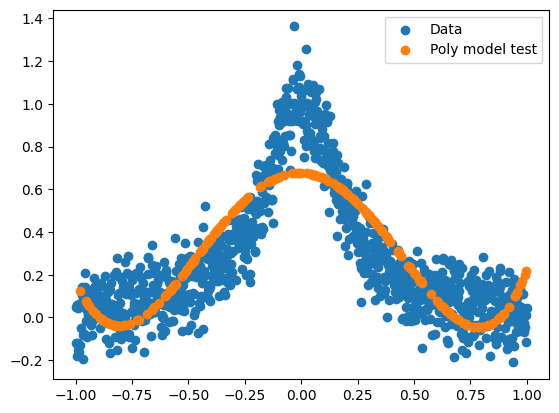

In [61]:
# Do a split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model on the training set and evaluate on the test set
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

beta = OLS_parameters(X_train, y_train)
poly_predict_test = X_test @ beta

poly_mse_test = mean_squared_error(y_test, poly_predict_test)

print(f"Poly model MSE on test set : {poly_mse_test}")

plt.scatter(x, y, label = "Data")
plt.scatter(X_test[:, 1], poly_predict_test, label = "Poly model test")

plt.legend()
plt.show()

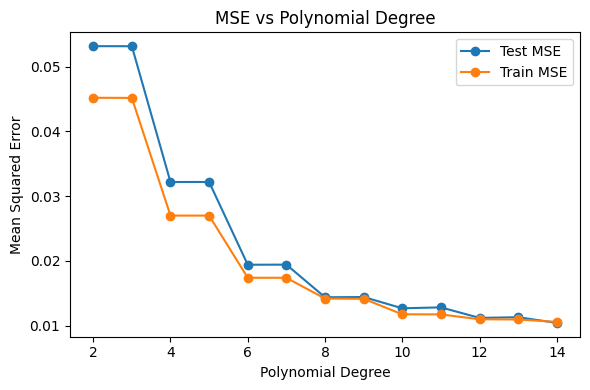

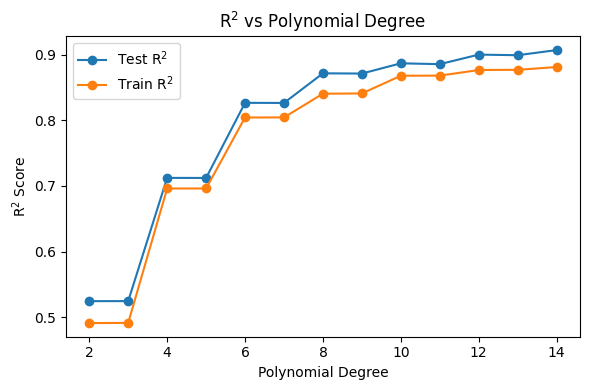

In [62]:
degrees = list(range(2, 15))
mse_test_values = []
mse_train_values = []
r2_test_values = []
r2_train_values = []

from sklearn.metrics import r2_score

for degree in degrees:
    X = polynomial_features(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    beta = OLS_parameters(X_train, y_train)
    poly_predict_test = X_test @ beta
    poly_predict_train = X_train @ beta

    poly_mse_test = mean_squared_error(y_test, poly_predict_test)
    poly_mse_train = mean_squared_error(y_train, poly_predict_train)

    r2_test = r2_score(y_test, poly_predict_test)
    r2_train = r2_score(y_train, poly_predict_train)

    mse_test_values.append(poly_mse_test)
    mse_train_values.append(poly_mse_train)
    r2_test_values.append(r2_test)
    r2_train_values.append(r2_train)

# Plot MSE vs degree
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_test_values, marker='o', label='Test MSE')
plt.plot(degrees, mse_train_values, marker='o', label='Train MSE')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Polynomial Degree")
plt.legend()
plt.tight_layout()
plt.show()

# Plot R^2 vs degree
plt.figure(figsize=(6,4))
plt.plot(degrees, r2_test_values, marker='o', label='Test R$^2$')
plt.plot(degrees, r2_train_values, marker='o', label='Train R$^2$')
plt.xlabel("Polynomial Degree")
plt.ylabel("R$^2$ Score")
plt.title("R$^2$ vs Polynomial Degree")
plt.legend()
plt.tight_layout()
plt.show()

The plot shows how the model's performance changes as we increase the polynomial degree. As the degree increases, the training MSE generally decreases, since the model gains more variance and can fit the training data better. Here we test polynomial degrees from 2 to 20. The trend is for the test MSE to decrease together with the training MSE. We want a model that keeps both errors low, indicating good generalization to the underlying data distribution. This tells me that we have not yet overfit the model at 20 polynomial degrees.

## Part B
### Adding Ridge regression for the Runge function
Write your own code for the Ridge method as done in the previous
exercise. The lecture notes from week 35 and 36 contain more
information. Furthermore, the results from the exercise set from week 36
is something you can reuse here.

Perform the same analysis as you did in the previous exercise but now
for different values of $\lambda$. Compare and analyze your results
with those obtained in part a) with the OLS method. Study the dependence
on $\lambda$.

In [63]:
def Ridge_parameters(X, y, lam=1.0):
    # Assuming scaled X and no intercept
    I = np.eye(X.shape[1])
    return np.linalg.inv(X.T @ X + lam * I) @ X.T @ y

beta_ridge = Ridge_parameters(X_train, y_train, lam=1.0)

y_predict_test = X_test @ beta_ridge
ridge_mse_test = mean_squared_error(y_test, y_predict_test)

Ridge model MSE on test set (lambda 1e-06): 0.011530031247713792
Ridge model MSE on test set (lambda 0.001): 0.01461102169290073
Ridge model MSE on test set (lambda 0.1): 0.02398679677135117
Ridge model MSE on test set (lambda 1): 0.03325182737590638
Ridge model MSE on test set (lambda 10): 0.05159204173399459
Ridge model MSE on test set (lambda 100): 0.08432154028989956


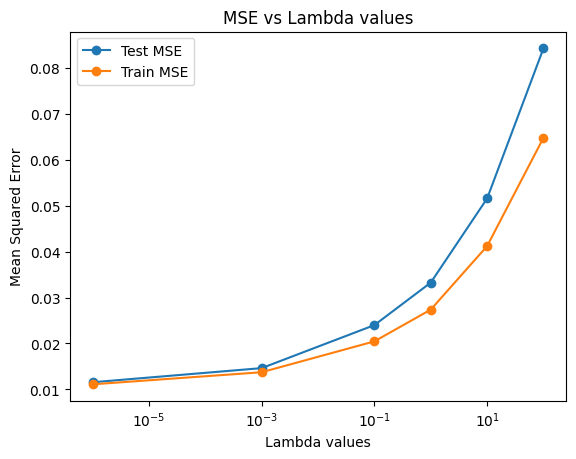

In [64]:
lambdas = [1e-6, 1e-3, 1e-1, 1, 10, 100]
mse_test_values_ridge = []
mse_train_values_ridge = []

for lam in lambdas:
  beta_ridge = Ridge_parameters(X_train, y_train, lam=lam)
  y_predict_test = X_test @ beta_ridge
  y_predict_train = X_train @ beta_ridge

  ridge_mse_test = mean_squared_error(y_test, y_predict_test)
  ridge_mse_train = mean_squared_error(y_train, y_predict_train)

  mse_test_values_ridge.append(ridge_mse_test)
  mse_train_values_ridge.append(ridge_mse_train)

  print(f"Ridge model MSE on test set (lambda {lam}): {ridge_mse_test}")
  #print(f"Ridge model MSE on train set (lambda {lam}): {ridge_mse_train}")

# plot all the MSE values against the lambda
plt.semilogx(lambdas, mse_test_values_ridge, marker='o', label='Test MSE')
plt.semilogx(lambdas, mse_train_values_ridge, marker='o', label='Train MSE')
plt.xlabel("Lambda values")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Lambda values")
plt.legend()
plt.show()

Comparing OLS with Ridge

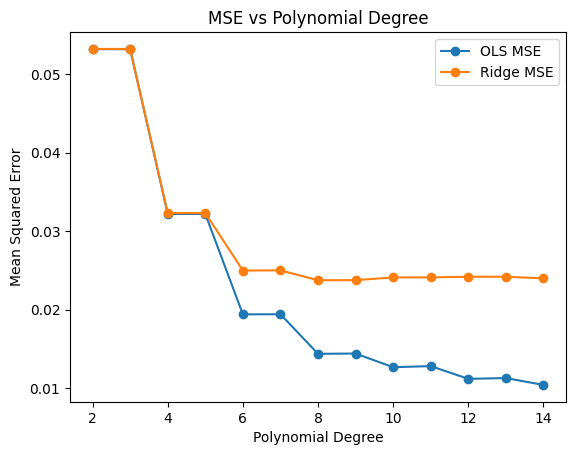

In [65]:
lambda_ridge = 0.1
mse_test_ridge = []

for degree in degrees:
    X = polynomial_features(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
    beta_ridge = Ridge_parameters(X_train, y_train, lam=lambda_ridge)
    poly_predict_test_ridge = X_test @ beta_ridge
    mse_test_ridge.append(mean_squared_error(y_test, poly_predict_test_ridge))

plt.plot(degrees, mse_test_values, marker='o', label='OLS MSE')
plt.plot(degrees, mse_test_ridge, marker='o', label='Ridge MSE')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Polynomial Degree")
plt.legend()
plt.show()

## Part C
### Writing your own gradient descent code

Replace now the analytical expressions for the optimal parameters
$\boldsymbol{\theta}$ with your own gradient descent code. In this
exercise we focus only on the simplest gradient descent approach with a
fixed learning rate (see the exercises from week 37 and the lecture
notes from week 36).

Study and compare your results from parts a) and b) with your gradient
descent approch. Discuss in particular the role of the learning rate.

Implementations of OLS and Ridge Gradient descent functions:

In [66]:
def gd_Ridge(X, y, lam=0.1, eta=0.001, num_iters=1000, tol=1e-6):

    n_features = X.shape[1]
    theta = np.zeros(n_features)

    for t in range(num_iters):
        grad = - X.T @ (y - X @ theta) + lam * theta
        theta_old = theta.copy()
        theta = theta - eta * grad

        if np.linalg.norm(theta - theta_old) < tol:
            # Converged
            print(f"Ridge converged after {t} iterations")
            break

    return theta


In [67]:
def gd_OLS(X, y, eta=0.001, num_iters=1000, tol=1e-6):

    n_features = X.shape[1]
    theta = np.zeros(n_features)

    for t in range(num_iters):
        grad = - X.T @ (y - X @ theta)
        theta_old = theta.copy()
        theta = theta - eta * grad

        if np.linalg.norm(theta - theta_old) < tol:
            # Converged
            print(f"OLS converged after {t} iterations")
            break

    return theta


Gradient descent vs poly degree

In [68]:
mse_test_values_gd = []
mse_train_values_gd = []

for degree in degrees:
    X = polynomial_features(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    beta_gd = gd_OLS(X_train, y_train)

    poly_predict_test_gd = X_test @ beta_gd
    poly_predict_train_gd = X_train @ beta_gd

    poly_mse_test_gd = mean_squared_error(y_test, poly_predict_test_gd)
    poly_mse_train_gd = mean_squared_error(y_train, poly_predict_train_gd)

    mse_test_values_gd.append(poly_mse_test_gd)
    mse_train_values_gd.append(poly_mse_train_gd)

OLS converged after 168 iterations
OLS converged after 449 iterations


In [69]:
mse_test_values_ridge_gd = []
mse_train_values_ridge_gd = []

for degree in degrees:
    X = polynomial_features(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    beta_ridge_gd = gd_Ridge(X_train, y_train)
    y_predict_test_ridge_gd = X_test @ beta_ridge_gd
    y_predict_train_ridge_gd = X_train @ beta_ridge_gd

    mse_test_ridge_gd = mean_squared_error(y_test, y_predict_test_ridge_gd)
    mse_train_ridge_gd = mean_squared_error(y_train, y_predict_train_ridge_gd)

    mse_test_values_ridge_gd.append(mse_test_ridge_gd)
    mse_train_values_ridge_gd.append(mse_train_ridge_gd)

Ridge converged after 167 iterations
Ridge converged after 446 iterations


Plotting analytical vs gd:

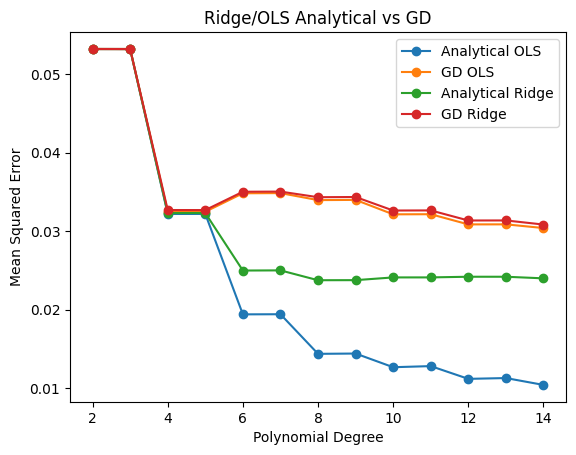

In [70]:
plt.plot(degrees, mse_test_values, marker='o', label='Analytical OLS')
plt.plot(degrees, mse_test_values_gd, marker='o', label='GD OLS')
plt.plot(degrees, mse_test_ridge, marker='o', label='Analytical Ridge')
plt.plot(degrees, mse_test_values_ridge_gd, marker='o', label='GD Ridge')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Ridge/OLS Analytical vs GD")
plt.legend()
plt.show()

## Part D
### Including momentum and more advanced ways to update the learning the rate
We keep our focus on OLS and Ridge regression and update our code for
the gradient descent method by including \textbf{momentum},
\textbf{ADAgrad}, \textbf{RMSprop} and \textbf{ADAM} as methods fro
iteratively updating your learning rate. Discuss the results and compare
the different methods applied to the one-dimensional Runge function. The
lecture notes from week 37 contain several examples on how to implement
these methods.

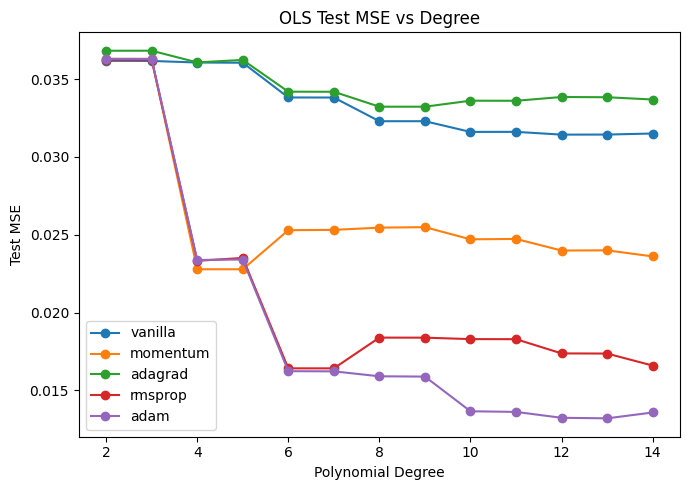

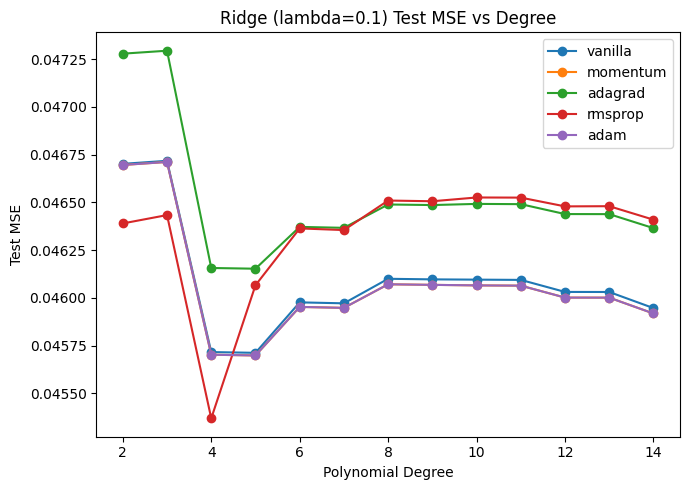

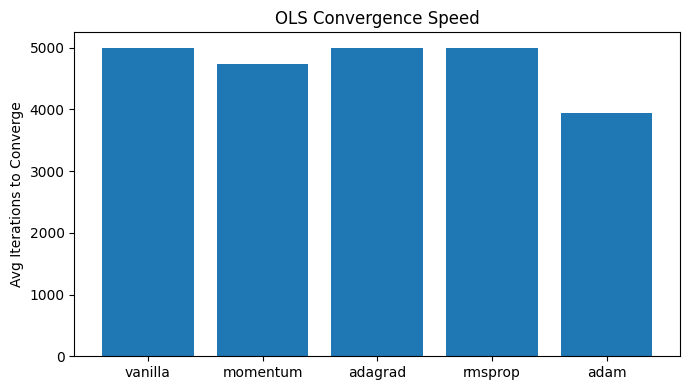

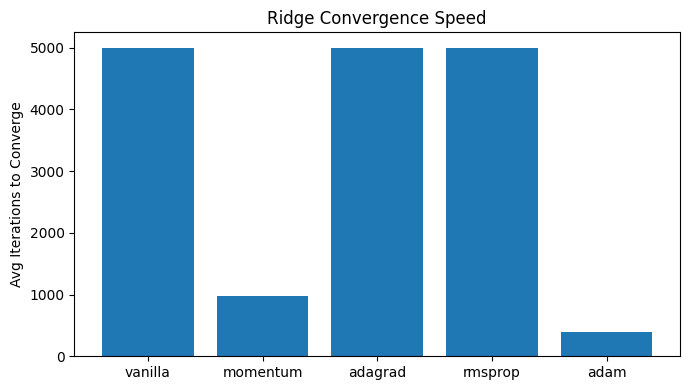

In [71]:
def gradient(theta, X, y, lam=0.0, ridge=False):
    n = X.shape[0]
    diff = X @ theta - y
    g = (2.0/n) * (X.T @ diff)
    if ridge and lam > 0.0:
        reg = theta.copy()
        reg[0] = 0.0
        g += 2.0 * lam * reg
    return g

class Optimizer:
    def __init__(self, name, eta=1e-2, mu=0.9, rho=0.9, beta1=0.9, beta2=0.999, eps=1e-8):
        self.name = name
        self.eta = eta
        self.mu = mu
        self.rho = rho
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self._m = None 
        self._v = None  
        self._t = 0

    def step(self, theta, g):
        if self._m is None:
            self._m = np.zeros_like(theta)
        if self._v is None:
            self._v = np.zeros_like(theta)

        if self.name == 'vanilla':
            theta = theta - self.eta * g
        elif self.name == 'momentum':
            self._m = self.mu * self._m - self.eta * g
            theta = theta + self._m
        elif self.name == 'adagrad':
            self._v += g**2
            theta = theta - self.eta * g / (np.sqrt(self._v) + self.eps)
        elif self.name == 'rmsprop':
            # exponential moving average of squared gradients
            self._v = self.rho * self._v + (1 - self.rho) * g**2
            theta = theta - self.eta * g / (np.sqrt(self._v) + self.eps)
        elif self.name == 'adam':
            self._t += 1
            self._m = self.beta1 * self._m + (1 - self.beta1) * g
            self._v = self.beta2 * self._v + (1 - self.beta2) * g**2
            m_hat = self._m / (1 - self.beta1**self._t)
            v_hat = self._v / (1 - self.beta2**self._t)
            theta = theta - self.eta * m_hat / (np.sqrt(v_hat) + self.eps)
        else:
            raise ValueError(f"Unknown optimizer {self.name}")
        return theta


def fit_full_batch(X_train, y_train, X_test, y_test, ridge_lambda, optimizer: Optimizer,
                   max_iters=5000, tol=1e-8, ridge=False):
    theta = np.zeros(X_train.shape[1])
    prev = theta.copy()
    for it in range(1, max_iters+1):
        g = gradient(theta, X_train, y_train, lam=ridge_lambda, ridge=ridge)
        theta = optimizer.step(theta, g)
        if np.linalg.norm(theta - prev) < tol:
            break
        prev = theta.copy()
    y_pred_test = X_test @ theta
    y_pred_train = X_train @ theta
    return {
        'theta': theta,
        'iters': it,
        'mse_test': mean_squared_error(y_test, y_pred_test),
        'mse_train': mean_squared_error(y_train, y_pred_train)
    }


np.random.seed(42)
N = 800
x_all = np.linspace(-1, 1, N)
noise = np.random.normal(0, 0.1, N)
y_all = runge_function(x_all) + noise
ridge_lambda = 0.1

optim_cfgs = [
    ('vanilla',  dict(eta=5e-3)),  
    ('momentum', dict(eta=5e-3, mu=0.9)),
    ('adagrad',  dict(eta=5e-3)),   
    ('rmsprop',  dict(eta=5e-3, rho=0.9)),
    ('adam',     dict(eta=5e-3, beta1=0.9, beta2=0.999))
]

ols_results = {name: [] for name,_ in optim_cfgs}
ridge_results = {name: [] for name,_ in optim_cfgs}
ols_iters = {name: [] for name,_ in optim_cfgs}
ridge_iters = {name: [] for name,_ in optim_cfgs}

for deg in degrees:
    X = polynomial_features(x_all, deg)
    X_train, X_test, y_train, y_test = train_test_split(X, y_all, test_size=0.2, random_state=1)
    for name, cfg in optim_cfgs:
        opt = Optimizer(name, **cfg)
        res_ols = fit_full_batch(X_train, y_train, X_test, y_test, ridge_lambda=0.0, optimizer=opt, ridge=False)
        ols_results[name].append(res_ols['mse_test'])
        ols_iters[name].append(res_ols['iters'])
        # new optimizer for ridge
        opt_r = Optimizer(name, **cfg)
        res_ridge = fit_full_batch(X_train, y_train, X_test, y_test, ridge_lambda=ridge_lambda, optimizer=opt_r, ridge=True)
        ridge_results[name].append(res_ridge['mse_test'])
        ridge_iters[name].append(res_ridge['iters'])

# Plot OLS
plt.figure(figsize=(7,5))
for name in ols_results:
    plt.plot(degrees, ols_results[name], marker='o', label=name)
plt.xlabel('Polynomial Degree')
plt.ylabel('Test MSE')
plt.title('OLS Test MSE vs Degree')
plt.legend(); plt.tight_layout(); plt.show()

# Plot Ridge
plt.figure(figsize=(7,5))
for name in ridge_results:
    plt.plot(degrees, ridge_results[name], marker='o', label=name)
plt.xlabel('Polynomial Degree')
plt.ylabel('Test MSE')
plt.title(f'Ridge (lambda={ridge_lambda}) Test MSE vs Degree')
plt.legend(); plt.tight_layout(); plt.show()

# Convergence iterations OLS
plt.figure(figsize=(7,4))
plt.bar(list(ols_iters.keys()), [np.mean(v) for v in ols_iters.values()])
plt.ylabel('Avg Iterations to Converge')
plt.title('OLS Convergence Speed')
plt.tight_layout(); plt.show()

# Convergence iterations Ridge
plt.figure(figsize=(7,4))
plt.bar(list(ridge_iters.keys()), [np.mean(v) for v in ridge_iters.values()])
plt.ylabel('Avg Iterations to Converge')
plt.title('Ridge Convergence Speed')
plt.tight_layout(); plt.show()

## Part E
### Writing our own code for Lasso regression
LASSO regression (see lecture slides from week 36 and week 37)
represents our first encounter with a machine learning method which
cannot be solved through analytical expressions (as in OLS and Ridge
regression). Use the gradient descent methods you developed in parts c)
and d) to solve the LASSO optimization problem. You can compare your
results with the functionalities of **Scikit-Learn**.

Discuss (critically) your results for the Runge function from OLS, Ridge
and LASSO regression using the various gradient descent approaches.

OLS Train/Test MSE: 0.00845 / 0.01194


c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.754e-03, tolerance: 5.763e-03
  model = cd_fast.enet_coordinate_descent(


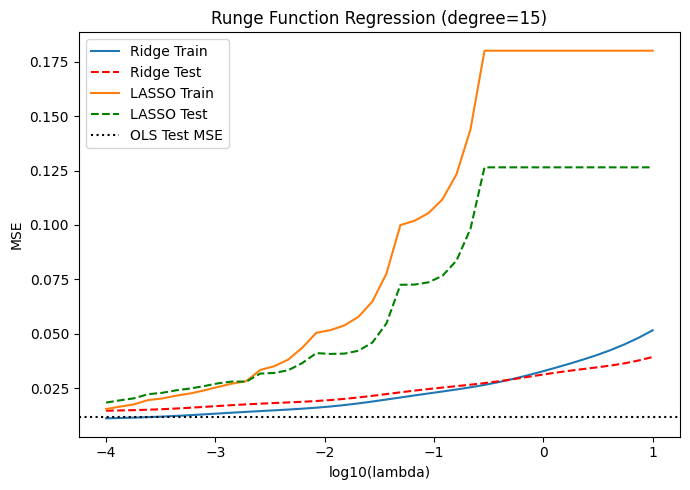

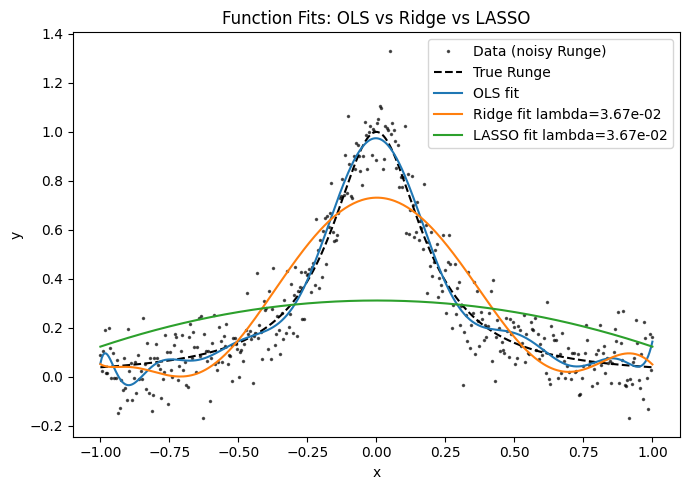

Min Ridge Test MSE: 0.01464 at lambda=0.0001
Min LASSO Test MSE: 0.01836 at lambda=0.0001


In [72]:
from sklearn import linear_model

def runge(x):
    return 1.0/(1+25*x**2)

def MSE(y_data, y_model):
    n = np.size(y_model)
    return np.sum((y_data - y_model)**2)/n

def R2(y_data, y_model):
    return 1 - np.sum((y_data - y_model)**2)/np.sum((y_data - np.mean(y_data))**2)

np.random.seed(42)
N = 400
x = np.linspace(-1, 1, N)
noise = 0.1*np.random.randn(N)
y = runge(x) + noise

# Choose a polynomial degree for lambda experiment
poly_degree = 15
p = poly_degree + 1 # 1 for intercept
X = np.zeros((N, p))
for d in range(p):
    X[:, d] = x**d

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# OLS
XT_X = X_train.T @ X_train
XT_y = X_train.T @ y_train
beta_OLS = np.linalg.pinv(XT_X) @ XT_y

y_train_hat_OLS = X_train @ beta_OLS
y_test_hat_OLS = X_test @ beta_OLS
mse_train_OLS = MSE(y_train, y_train_hat_OLS)
mse_test_OLS  = MSE(y_test,  y_test_hat_OLS)

print(f"OLS Train/Test MSE: {mse_train_OLS:.5f} / {mse_test_OLS:.5f}")

# Ridge / LASSO lambda experiment
nlambdas = 40
lambdas = np.logspace(-4, 1, nlambdas)

MSE_Ridge_train = np.zeros(nlambdas)
MSE_Ridge_test  = np.zeros(nlambdas)
MSE_Lasso_train = np.zeros(nlambdas)
MSE_Lasso_test  = np.zeros(nlambdas)

I = np.eye(p)

for i, lmb in enumerate(lambdas):
    # Ridge 
    beta_ridge = np.linalg.pinv(XT_X + lmb*I) @ XT_y
    ytr_ridge = X_train @ beta_ridge
    yte_ridge = X_test @ beta_ridge
    MSE_Ridge_train[i] = MSE(y_train, ytr_ridge)
    MSE_Ridge_test[i]  = MSE(y_test,  yte_ridge)

    # LASSO via scikit-learn with fit_intercept=False
    lasso_model = linear_model.Lasso(alpha=lmb, fit_intercept=False, max_iter=20000)
    lasso_model.fit(X_train, y_train)
    ytr_lasso = lasso_model.predict(X_train)
    yte_lasso = lasso_model.predict(X_test)
    MSE_Lasso_train[i] = MSE(y_train, ytr_lasso)
    MSE_Lasso_test[i]  = MSE(y_test,  yte_lasso)

# Plot MSE vs log10(lambda)
plt.figure(figsize=(7,5))
plt.plot(np.log10(lambdas), MSE_Ridge_train, label='Ridge Train')
plt.plot(np.log10(lambdas), MSE_Ridge_test,  'r--', label='Ridge Test')
plt.plot(np.log10(lambdas), MSE_Lasso_train, label='LASSO Train')
plt.plot(np.log10(lambdas), MSE_Lasso_test,  'g--', label='LASSO Test')
plt.axhline(mse_test_OLS, color='k', ls=':', label='OLS Test MSE')
plt.xlabel('log10(lambda)')
plt.ylabel('MSE')
plt.title(f'Runge Function Regression (degree={poly_degree})')
plt.legend()
plt.tight_layout()
plt.show()

# Inspect one lambda in the middle for comparison
mid_idx = nlambdas//2

# plot fitted curves for selected methods
x_plot = np.linspace(-1,1,400)
X_plot = np.zeros((len(x_plot), p))
for d in range(p):
    X_plot[:, d] = x_plot**d

beta_ridge_mid = np.linalg.pinv(XT_X + lambdas[mid_idx]*I) @ XT_y
lasso_mid = linear_model.Lasso(alpha=lambdas[mid_idx], fit_intercept=False, max_iter=20000).fit(X_train, y_train)

plt.figure(figsize=(7,5))
plt.plot(x, y, 'k.', ms=3, alpha=0.6, label='Data (noisy Runge)')
plt.plot(x_plot, runge(x_plot), 'k--', label='True Runge')
plt.plot(x_plot, X_plot @ beta_OLS, label='OLS fit')
plt.plot(x_plot, X_plot @ beta_ridge_mid, label=f'Ridge fit lambda={lambdas[mid_idx]:.2e}')
plt.plot(x_plot, lasso_mid.predict(X_plot), label=f'LASSO fit lambda={lambdas[mid_idx]:.2e}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Function Fits: OLS vs Ridge vs LASSO')
plt.legend(); plt.tight_layout(); plt.show()

# Print minimal test MSEs for summary
print(f"Min Ridge Test MSE: {MSE_Ridge_test.min():.5f} at lambda={lambdas[MSE_Ridge_test.argmin()]:.4g}")
print(f"Min LASSO Test MSE: {MSE_Lasso_test.min():.5f} at lambda={lambdas[MSE_Lasso_test.argmin()]:.4g}")


## Part F
### Stochastic gradient descent
Our last gradient step is to include stochastic gradient descent using
the same methods to update the learning rates as in parts c-e). Compare
and discuss your results with and without stochastic gradient and give a
critical assessment of the various methods.

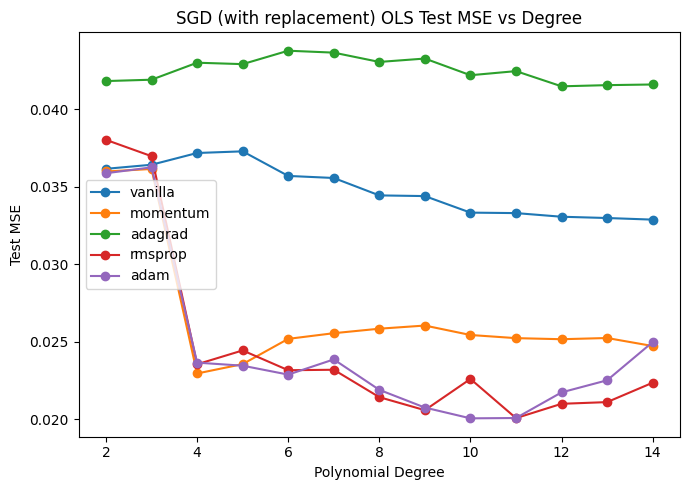

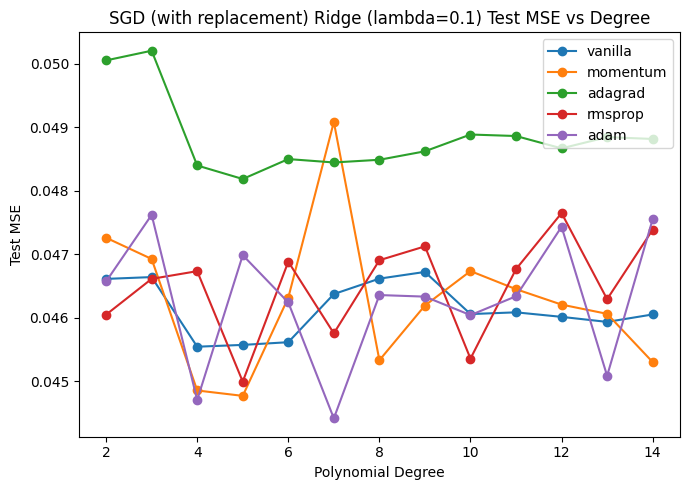

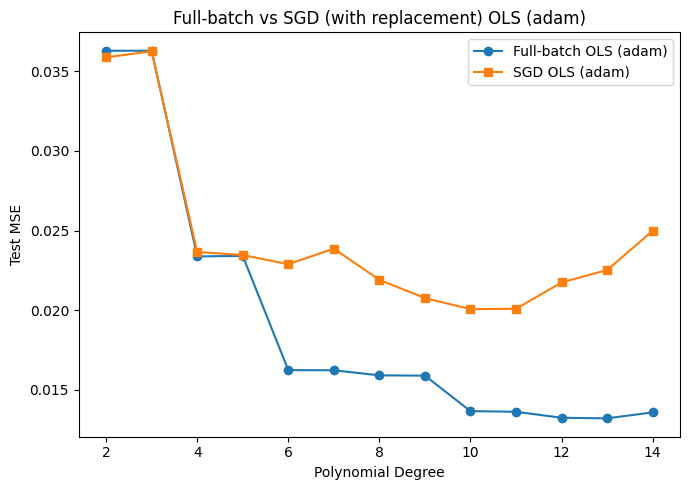

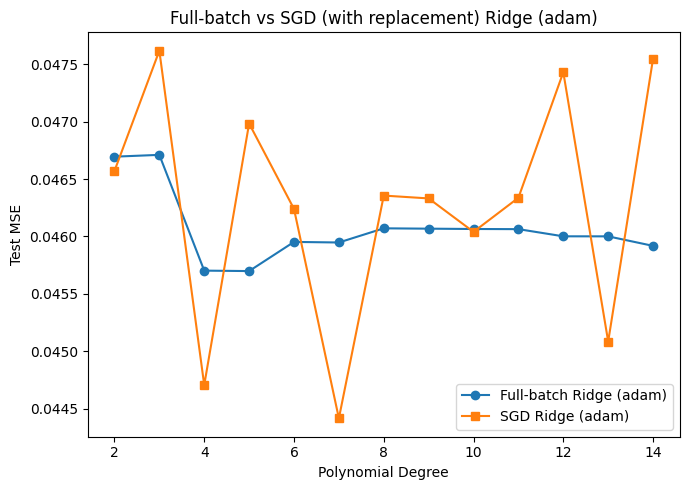

In [ ]:
# Now we update parameters using mini-batches with replacement. We compare test MSE vs polynomial degree.
# This version modifies fit_sgd so every mini-batch is drawn independently with replacement.

# SGD training loop
def fit_sgd(X_train, y_train, X_test, y_test, ridge_lambda, optimizer: 'Optimizer',
            ridge=False, epochs=100, batch_size=16, tol=1e-8):
    n_samples, n_features = X_train.shape
    theta = np.zeros(n_features)
    prev_epoch_theta = theta.copy()
    updates = 0
    n_batches = int(np.ceil(n_samples / batch_size))
    for epoch in range(1, epochs+1):
        for _ in range(n_batches):
            # Sample indices WITH replacement
            idx = np.random.randint(0, n_samples, size=batch_size)
            Xb = X_train[idx]
            yb = y_train[idx]
            g = gradient(theta, Xb, yb, lam=ridge_lambda, ridge=ridge)
            theta = optimizer.step(theta, g)
            updates += 1
        if np.linalg.norm(theta - prev_epoch_theta) < tol:
            break
        prev_epoch_theta = theta.copy()
    y_pred_test = X_test @ theta
    y_pred_train = X_train @ theta
    return {
        'theta': theta,
        'epoch': epoch,
        'updates': updates,
        'mse_test': mean_squared_error(y_test, y_pred_test),
        'mse_train': mean_squared_error(y_train, y_pred_train)
    }

np.random.seed(42)
N = 800
x_all = np.linspace(-1, 1, N)
noise = np.random.normal(0, 0.1, N)
y_all = runge_function(x_all) + noise
ridge_lambda = 0.1

# Optimizer configs, same as previous.
optim_cfgs = [
    ('vanilla',  dict(eta=5e-3)),  
    ('momentum', dict(eta=5e-3, mu=0.9)),
    ('adagrad',  dict(eta=5e-3)),   
    ('rmsprop',  dict(eta=5e-3, rho=0.9)),
    ('adam',     dict(eta=5e-3, beta1=0.9, beta2=0.999))
]

sgd_ols_results = {name: [] for name,_ in optim_cfgs}
sgd_ridge_results = {name: [] for name,_ in optim_cfgs}
sgd_ols_epochs = {name: [] for name,_ in optim_cfgs}
sgd_ridge_epochs = {name: [] for name,_ in optim_cfgs}

# Main loop over polynomial degrees
for deg in degrees:
    X = polynomial_features(x_all, deg)
    X_train, X_test, y_train, y_test = train_test_split(X, y_all, test_size=0.2, random_state=1)
    for name, cfg in optim_cfgs:
        # OLS
        opt = Optimizer(name, **cfg)
        res_ols = fit_sgd(X_train, y_train, X_test, y_test, ridge_lambda=0.0, optimizer=opt, ridge=False)
        sgd_ols_results[name].append(res_ols['mse_test'])
        sgd_ols_epochs[name].append(res_ols['epoch'])
        # Ridge
        opt_r = Optimizer(name, **cfg)
        res_ridge = fit_sgd(X_train, y_train, X_test, y_test, ridge_lambda=ridge_lambda, optimizer=opt_r, ridge=True)
        sgd_ridge_results[name].append(res_ridge['mse_test'])
        sgd_ridge_epochs[name].append(res_ridge['epoch'])

# Plotting SGD Test MSE vs Degree OLS
plt.figure(figsize=(7,5))
for name in sgd_ols_results:
    plt.plot(degrees, sgd_ols_results[name], marker='o', label=name)
plt.xlabel('Polynomial Degree')
plt.ylabel('Test MSE')
plt.title('SGD (with replacement) OLS Test MSE vs Degree')
plt.legend(); plt.tight_layout(); plt.show()

# Plotting SGD Test MSE vs Degree Ridge
plt.figure(figsize=(7,5))
for name in sgd_ridge_results:
    plt.plot(degrees, sgd_ridge_results[name], marker='o', label=name)
plt.xlabel('Polynomial Degree')
plt.ylabel('Test MSE')
plt.title(f'SGD (with replacement) Ridge (lambda={ridge_lambda}) Test MSE vs Degree')
plt.legend(); plt.tight_layout(); plt.show()

key = 'adam' if 'adam' in ols_results else list(ols_results.keys())[0]
plt.figure(figsize=(7,5))
plt.plot(degrees, ols_results[key], marker='o', label=f'Full-batch OLS ({key})')
plt.plot(degrees, sgd_ols_results[key], marker='s', label=f'SGD OLS ({key})')
plt.xlabel('Polynomial Degree')
plt.ylabel('Test MSE')
plt.title(f'Full-batch vs SGD (with replacement) OLS ({key})')
plt.legend(); plt.tight_layout(); plt.show()

if key in ridge_results:
    plt.figure(figsize=(7,5))
    plt.plot(degrees, ridge_results[key], marker='o', label=f'Full-batch Ridge ({key})')
    plt.plot(degrees, sgd_ridge_results[key], marker='s', label=f'SGD Ridge ({key})')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('Test MSE')
    plt.title(f'Full-batch vs SGD (with replacement) Ridge ({key})')
    plt.legend(); plt.tight_layout(); plt.show()

The SGD results are a lot less stable. This is expected due to the random mini-batch training. SInce each epoch is updated according to the average loss of the minibatch, the loss depends on the selection of the mini-batch which can 

## Part G
### Bias-variance trade-off and resampling techniques
Our aim here is to study the bias-variance trade-off by implementing the
\textbf{bootstrap} resampling technique. \textbf{We will only use the
simpler ordinary least squares here}.

With a code which does OLS and includes resampling techniques, we will
now discuss the bias-variance trade-off in the context of continuous
predictions such as regression. However, many of the intuitions and
ideas discussed here also carry over to classification tasks and
basically all Machine Learning algorithms.

Before you perform an analysis of the bias-variance trade-off on your
test data, make first a figure similar to Fig. 2.11 of Hastie,
Tibshirani, and Friedman. Figure 2.11 of this reference displays only
the test and training MSEs. The test MSE can be used to indicate
possible regions of low/high bias and variance. You will most likely not
get an equally smooth curve! You may also need to increase the
polynomial order and play around with the number of data points as well
(see also the exercise set from week 35).

With this result we move on to the bias-variance trade-off analysis.

Consider a dataset $\mathcal{L}$ consisting of the data
$\mathbf{X}_\mathcal{L}=\{(y_j, \boldsymbol{x}_j), j=0\ldots n-1\}$.

We assume that the true data is generated from a noisy model

$$
\boldsymbol{y}=f(\boldsymbol{x}) + \boldsymbol{\epsilon}.
$$

Here $\epsilon$ is normally distributed with mean zero and standard
deviation $\sigma^2$.

In our derivation of the ordinary least squares method we defined then
an approximation to the function $f$ in terms of the parameters
$\boldsymbol{\theta}$ and the design matrix $\boldsymbol{X}$ which
embody our model, that is
$\boldsymbol{\tilde{y}}=\boldsymbol{X}\boldsymbol{\theta}$.

The parameters $\boldsymbol{\theta}$ are in turn found by optimizing
the mean squared error via the so-called cost function

$$
C(\boldsymbol{X},\boldsymbol{\theta}) =\frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2=\mathbb{E}\left[(\boldsymbol{y}-\boldsymbol{\tilde{y}})^2\right].
$$

Here the expected value $\mathbb{E}$ is the sample value.

Show that you can rewrite this in terms of a term which contains the
variance of the model itself (the so-called variance term), a term which
measures the deviation from the true data and the mean value of the
model (the bias term) and finally the variance of the noise.

That is, show that

$$
\mathbb{E}\left[(\boldsymbol{y}-\boldsymbol{\tilde{y}})^2\right]=\mathrm{Bias}[\tilde{y}]+\mathrm{var}[\tilde{y}]+\sigma^2,
$$

with (we approximate $f(\boldsymbol{x})\approx \boldsymbol{y}$)

$$
\mathrm{Bias}[\tilde{y}]=\mathbb{E}\left[\left(\boldsymbol{y}-\mathbb{E}\left[\boldsymbol{\tilde{y}}\right]\right)^2\right],
$$

and

$$
\mathrm{var}[\tilde{y}]=\mathbb{E}\left[\left(\tilde{\boldsymbol{y}}-\mathbb{E}\left[\boldsymbol{\tilde{y}}\right]\right)^2\right]=\frac{1}{n}\sum_i(\tilde{y}_i-\mathbb{E}\left[\boldsymbol{\tilde{y}}\right])^2.
$$

\textbf{Important note}: Since the function $f(x)$ is unknown, in
order to be able to evalute the bias, we replace $f(\boldsymbol{x})$
in the expression for the bias with $\boldsymbol{y}$.

The answer to this exercise should be included in the theory part of the
report. This exercise is also part of the weekly exercises of week 38.
Explain what the terms mean and discuss their interpretations.

Perform then a bias-variance analysis of the Runge function by studying
the MSE value as function of the complexity of your model.

Discuss the bias and variance trade-off as function of your model
complexity (the degree of the polynomial) and the number of data points,
and possibly also your training and test data using the
\textbf{bootstrap} resampling method. You can follow the code example in
the jupyter-book at
\url{https://compphysics.github.io/MachineLearning/doc/LectureNotes/_build/html/chapter3.html\#the-bias-variance-tradeoff}.


  ## Rewriting the MSE optimization in terms of bias, variance and noise

Starting with the definition of the MSE:

$$
\mathbb{E}[(\boldsymbol{y} - \tilde{\boldsymbol{y}})^2] = \mathbb{E}[(\boldsymbol{y} - \mathbb{E}[\tilde{\boldsymbol{y}}] + \mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})^2]
$$

Expanding the squares:

$$
= \mathbb{E}[(\boldsymbol{y} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2]
+ 2\mathbb{E}[(\boldsymbol{y} - \mathbb{E}[\tilde{\boldsymbol{y}}])(\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})]
+ (\mathbb{E}[\tilde{\boldsymbol{y}}] - \tilde{\boldsymbol{y}})^2
$$

Since $\mathbb{E}[\tilde{\boldsymbol{y}}]$ is the expected prediction, and the errors are independent, we can zero out the cross-term. Then:

$$
\mathbb{E}[(\boldsymbol{y} - \tilde{\boldsymbol{y}})^2] = \mathbb{E}[(\boldsymbol{y} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2] + \mathbb{E}[(\tilde{\boldsymbol{y}}
- \mathbb{E}[\tilde{\boldsymbol{y}}])^2]
$$

And if we substitute back in $ \boldsymbol{y}=f(\boldsymbol{x}) + \boldsymbol{\epsilon}$, then:

$$
\mathbb{E}[(\boldsymbol{y} - \mathbb{E}[\tilde{\boldsymbol{y}}])^2]
= (f(x) - \mathbb{E}[\tilde{\boldsymbol{y}}])^2 +\mathbb{E}[\epsilon^2]
$$
Finally:
$$
\mathbb{E}[(\boldsymbol{y} - \tilde{\boldsymbol{y}})^2] = \mathbb{E}[(f(x) - \mathbb{E}[\tilde{\boldsymbol{y}}])^2] + \mathbb{E}[(\tilde{\boldsymbol{y}}
- \mathbb{E}[\tilde{\boldsymbol{y}}])^2] +\sigma^2
$$

The bias term is the squared difference between the expected prediction and the true value, the second term is the variance of the noise, $\sigma^2$, the second term is the variance of the model's predictions:

$$
\mathbb{E}[(\boldsymbol{y} - \tilde{\boldsymbol{y}})^2] = \text{Bias}[\tilde{\boldsymbol{y}}] + \text{Var}[\tilde{\boldsymbol{y}}] + \sigma^2
$$

## Interpretation of the Terms

- **Bias** - The inability for a machine learning method to capture the true relationship. Measures the error introduced by approximating a problem, by a simplified model. A high bias indicates that the model makes strong assumptions about the data, potentially leading to underfitting.

- **Variance** - The difference in fits between the datasets. Reflects the model's sensitivity to fluctuations in the training set. High variance suggests that the model is overfitting, capturing noise rather than the data.

- **Noise ($\sigma^2$)** - The error originating from variability in the data that cannot be explained by the model.


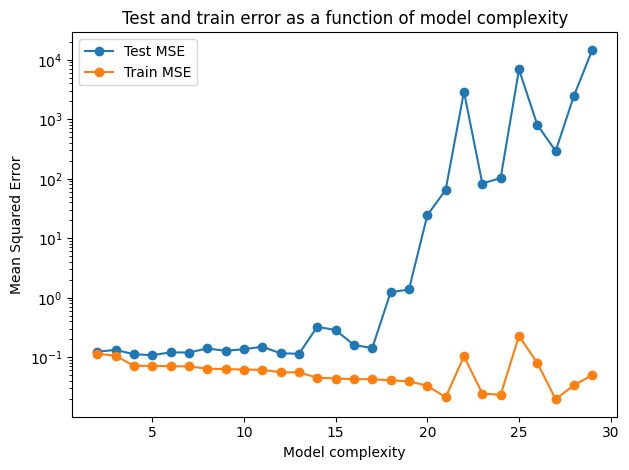

In [74]:
degrees = list(range(2, 30))

# Generate synthetic data
n = 50
x = np.linspace(-1, 1, n)
y = runge_function(x) + np.random.normal(0, 0.3, n)

mse_test_values2 = []
mse_train_values2 = []

for degree in degrees:
    X = polynomial_features(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    beta = OLS_parameters(X_train, y_train)
    poly_predict_test = X_test @ beta
    poly_predict_train = X_train @ beta

    poly_mse_test = mean_squared_error(y_test, poly_predict_test)
    poly_mse_train = mean_squared_error(y_train, poly_predict_train)

    mse_test_values2.append(poly_mse_test)
    mse_train_values2.append(poly_mse_train)

# Plot MSE vs degree
plt.semilogy(degrees, mse_test_values2, marker='o', label='Test MSE')
plt.semilogy(degrees, mse_train_values2, marker='o', label='Train MSE')
plt.xlabel("Model complexity")
plt.ylabel("Mean Squared Error")
plt.title("Test and train error as a function of model complexity")
plt.legend()
plt.tight_layout()
plt.show()

Now Bias/variance with bootstrap - adapting code from lecture notes week38

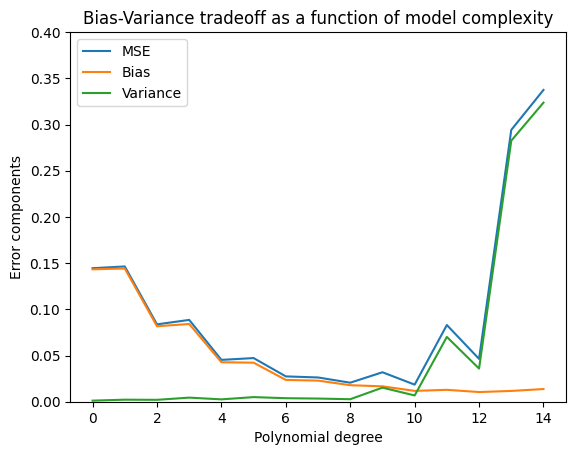

In [75]:
from sklearn.utils import resample

np.random.seed(42)
n =70
n_bootstraps = 100
maxdegree = 15

x = np.linspace(-1, 1, n)
y = runge_function(x) + np.random.normal(0, 0.1, n)

X_all = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=1)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)


for degree in range(maxdegree):
    X_train_poly = polynomial_features(X_train.flatten(), degree)
    X_test_poly = polynomial_features(X_test.flatten(), degree)
    
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    
    for i in range(n_bootstraps):
        X_res, y_res = resample(X_train_poly, y_train)
        
        beta = OLS_parameters(X_res, y_res)
        
        y_pred[:, i] = X_test_poly @ beta
    
    error[degree] = np.mean((y_test.reshape(-1,1) - y_pred)**2)
    bias[degree] = np.mean((y_test.reshape(-1,1) - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    
    #print(f"Degree {degree}: Error={error[degree]:.4f}, Bias^2={bias[degree]:.4f}, Var={variance[degree]:.4f}")


plt.plot(range(maxdegree), error, label="MSE")
plt.plot(range(maxdegree), bias, label="Bias")
plt.plot(range(maxdegree), variance, label="Variance")
plt.ylim(top=0.4)
plt.ylim(bottom=0)
plt.xlabel("Polynomial degree")
plt.ylabel("Error components")
plt.title("Bias-Variance tradeoff as a function of model complexity")
plt.legend()
plt.show()


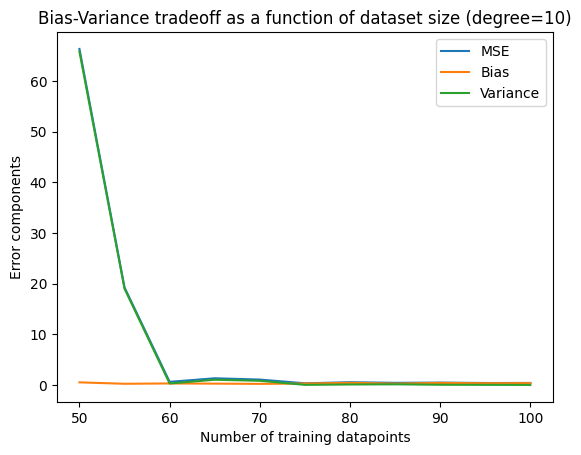

In [76]:
np.random.seed(42)
n_bootstraps = 100
degree = 10
n_points_list = list(range(50, 101, 5))

error = np.zeros(len(n_points_list))
bias = np.zeros(len(n_points_list))
variance = np.zeros(len(n_points_list))

for idx, n in enumerate(n_points_list):
    
    x = np.linspace(-1, 1, n)
    y = runge_function(x) + np.random.normal(0, 0.5, n)

    X_all = x.reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=1)

    
    X_train_poly = polynomial_features(X_train.flatten(), degree)
    X_test_poly = polynomial_features(X_test.flatten(), degree)

    
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    for i in range(n_bootstraps):
        X_res, y_res = resample(X_train_poly, y_train)
        beta = OLS_parameters(X_res, y_res)
        y_pred[:, i] = X_test_poly @ beta

    
    error[idx] = np.mean((y_test.reshape(-1,1) - y_pred)**2)
    bias[idx] = np.mean((y_test.reshape(-1,1) - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[idx] = np.mean(np.var(y_pred, axis=1, keepdims=True))

    #print(f"n={n}: Error={error[idx]:.4f}, Bias^2={bias[idx]:.4f}, Var={variance[idx]:.4f}")


plt.plot(n_points_list, error, label="MSE")
plt.plot(n_points_list, bias, label="Bias")
plt.plot(n_points_list, variance, label="Variance")
plt.xlabel("Number of training datapoints")
plt.ylabel("Error components")
plt.title(f"Bias-Variance tradeoff as a function of dataset size (degree={degree})")
plt.legend()
plt.show()


## Part H
### Cross-validation as resampling techniques, adding more complexity
The aim here is to implement another widely popular resampling
technique, the so-called cross-validation method.

Implement the $k$-fold cross-validation algorithm (feel free to use
the functionality of \textbf{Scikit-Learn} or write your own code) and
evaluate again the MSE function resulting from the test folds.

Compare the MSE you get from your cross-validation code with the one you
got from your \textbf{bootstrap} code from the previous exercise.
Comment and interpret your results.

In addition to using the ordinary least squares method, you should
include both Ridge and Lasso regression in the final analysis.

Example from lecture notes:

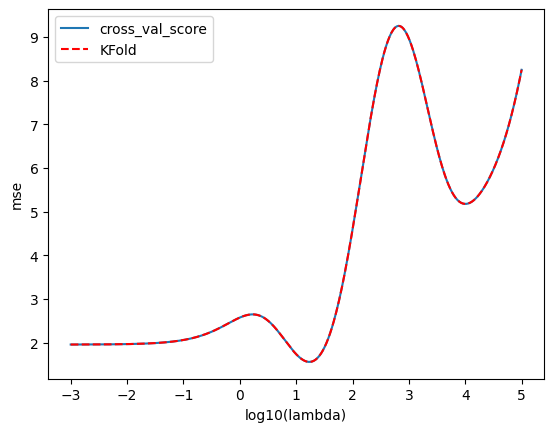

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures

# A seed just to ensure that the random numbers are the same for every run.
# Useful for eventual debugging.
np.random.seed(3155)

# Generate the data.
nsamples = 100
x = np.random.randn(nsamples)
y = 3*x**2 + np.random.randn(nsamples)

## Cross-validation on Ridge regression using KFold only

# Decide degree on polynomial to fit
poly = PolynomialFeatures(degree = 6)

# Decide which values of lambda to use
nlambdas = 500
lambdas = np.logspace(-3, 5, nlambdas)

# Initialize a KFold instance
k = 5
kfold = KFold(n_splits = k)

# Perform the cross-validation to estimate MSE
scores_KFold = np.zeros((nlambdas, k))

i = 0
for lmb in lambdas:
    ridge = Ridge(alpha = lmb)
    j = 0
    for train_inds, test_inds in kfold.split(x):
        xtrain = x[train_inds]
        ytrain = y[train_inds]

        xtest = x[test_inds]
        ytest = y[test_inds]

        Xtrain = poly.fit_transform(xtrain[:, np.newaxis])
        ridge.fit(Xtrain, ytrain[:, np.newaxis])

        Xtest = poly.fit_transform(xtest[:, np.newaxis])
        ypred = ridge.predict(Xtest)

        scores_KFold[i,j] = np.sum((ypred - ytest[:, np.newaxis])**2)/np.size(ypred)

        j += 1
    i += 1


estimated_mse_KFold = np.mean(scores_KFold, axis = 1)

## Cross-validation using cross_val_score from sklearn along with KFold

# kfold is an instance initialized above as:
# kfold = KFold(n_splits = k)

estimated_mse_sklearn = np.zeros(nlambdas)
i = 0
for lmb in lambdas:
    ridge = Ridge(alpha = lmb)

    X = poly.fit_transform(x[:, np.newaxis])
    estimated_mse_folds = cross_val_score(ridge, X, y[:, np.newaxis], scoring='neg_mean_squared_error', cv=kfold)

    # cross_val_score return an array containing the estimated negative mse for every fold.
    # we have to the the mean of every array in order to get an estimate of the mse of the model
    estimated_mse_sklearn[i] = np.mean(-estimated_mse_folds)

    i += 1

## Plot and compare the slightly different ways to perform cross-validation

plt.figure()

plt.plot(np.log10(lambdas), estimated_mse_sklearn, label = 'cross_val_score')
plt.plot(np.log10(lambdas), estimated_mse_KFold, 'r--', label = 'KFold')

plt.xlabel('log10(lambda)')
plt.ylabel('mse')

plt.legend()

plt.show()